# **Decision Tree Classifier**

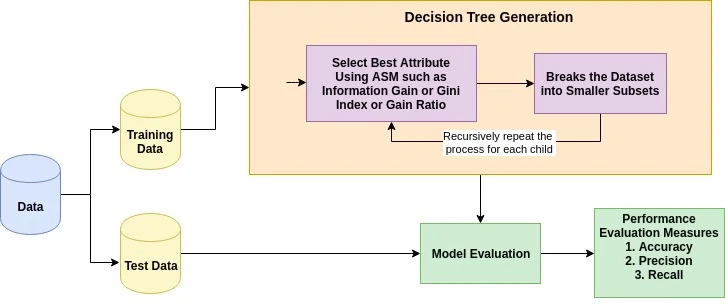

In [2]:
!pip install --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 23.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


# 1. Import libraries

In [3]:
import numpy as np # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # data visualization
import sklearn # machine learning

# 2. Import dataset
sklearn documentation : https://scikit-learn.org/stable/

In [4]:
from sklearn.datasets import load_iris
iris=load_iris()
type(iris.DESCR)
# import iris dataset with sklearn.datasets


str

## For reference, here are pictures of the three flowers species:

![https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Machine+Learning+R/iris-machinelearning.png](https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Machine+Learning+R/iris-machinelearning.png)

# 3. Dataset to Pandas DataFrame
Pandas Documentation : https://pandas.pydata.org/docs/reference/frame.html

In [5]:
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target

In [6]:
# First 10 values of the dataset

print(df_iris.head(10))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
5       0  
6       0  
7       0  
8       0  
9       0 

# 4. Exploratory data analysis

In [7]:
# Shape of the dataset (nb of rows and columns)
print(df_iris.shape)
# Name of the columns
print(df_iris.columns)

(150, 5)
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')


In [ ]:
#Information about the dataset DataFrame
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [ ]:
# Description of Iris dataset (mean, std, min, max, quartiles)
print(df_iris.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


### Frequency distribution of values in categorical variables

In [8]:
# Names of the target values
print(iris.target_names)
# Count of each target value
print(df_iris["target"].value_counts())
# Same as above but in percentage
print(df_iris['target'].value_counts(normalize=100))

['setosa' 'versicolor' 'virginica']
target
0    50
1    50
2    50
Name: count, dtype: int64
target
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64


### Missing values in variables

In [9]:
df_iris.isnull() #affiche boolean si c'est null ou pas
print(df_iris.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


## Correlation between variables

In [10]:
# Correlation matrix between all the features
df_iris.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


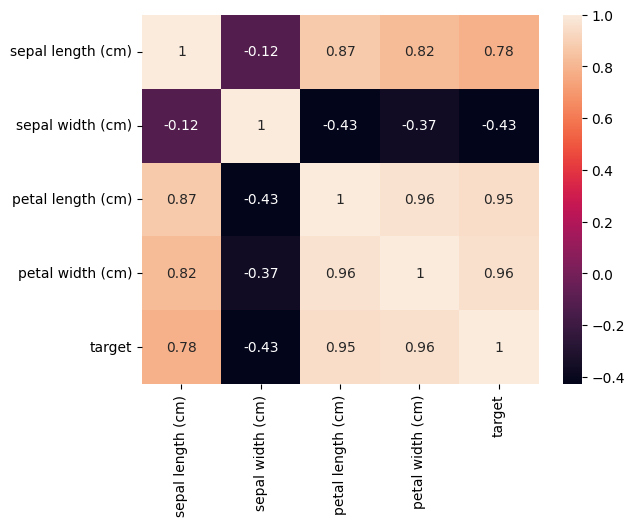

In [11]:
# Heatmap of the correlation matrix using seaborn https://seaborn.pydata.org/generated/seaborn.heatmap.html
plt.title('')
sns.heatmap(df_iris.corr(),annot=True)
plt.show()

In [12]:
# print the most correlated features with the target variable (absolute value)
print(df_iris.corr()['target'].abs().sort_values(ascending=False))

target               1.000000
petal width (cm)     0.956547
petal length (cm)    0.949035
sepal length (cm)    0.782561
sepal width (cm)     0.426658
Name: target, dtype: float64


### Visualizing the data

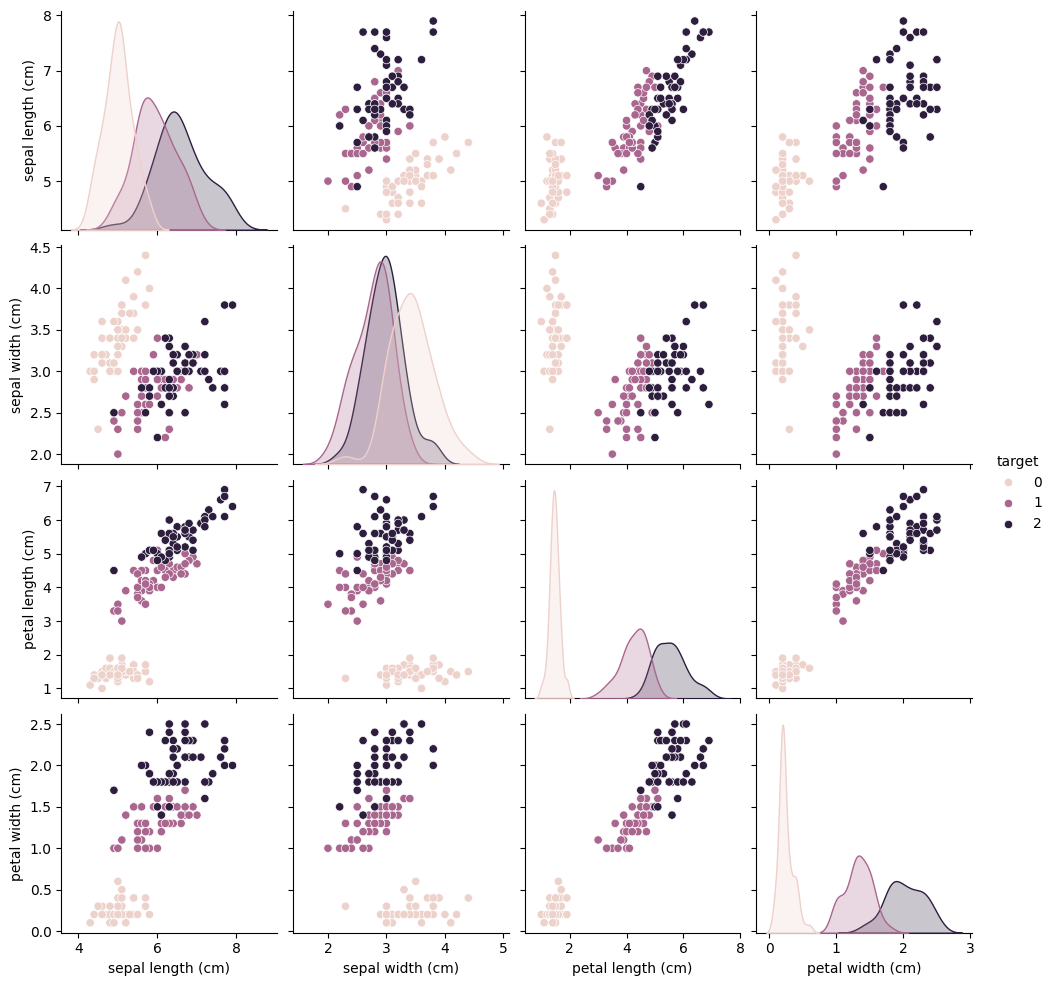

In [13]:
# Plot the pairwise relations in the iris dataset
sns.pairplot(df_iris, hue='target', height=2.5)
plt.show()

# 5. Declare features vector and target variable

In [15]:
# X is the feature set and y is the target variable
X=df_iris.drop(['target'],axis=1)
y=df_iris['target']

# 6. Split data into separate training and test sets

In [16]:
# Use sklearn.model_selection
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=42)

In [17]:
# Check the shapes of each subset
print(X_train.shape,X_test.shape)
print(y_train.shape,y_test.shape)


(100, 4) (50, 4)
(100,) (50,)


In [18]:
# Count the unique values in each of the subsets
print(y_train.value_counts())
print(y_test.value_counts())

target
1    35
2    34
0    31
Name: count, dtype: int64
target
0    19
2    16
1    15
Name: count, dtype: int64


# 7. Feature Engineering - Data Encoding

**Feature Engineering** is the process of transforming raw data into useful features that help us to understand our model better and increase its predictive power.

In [19]:
# check data types in X_train
X_train.dtypes


,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64


# 8. Decision Tree Classifier with criterion gini index

---

In [22]:
from sklearn.tree import DecisionTreeClassifier

# instantiate the DecisionTreeClassifier model with criterion gini index
clf_gini = DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=0)


# fit the model aka train the model on X_train
clf_gini.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

### Predict the Test set results with criterion gini index

In [23]:
y_pred_gini = clf_gini.predict(X_test)
X_test
X_test.iloc[0]#CA CHOISIT JUSTE LA PREMIERE CASE
y_pred_gini

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0, 1, 1, 2, 1, 2])

### Check accuracy score with criterion gini index using sklearn.metrics

In [24]:
from sklearn.metrics import accuracy_score
print('Model accuracy score with criterion geni index : {0:0.4f}'.format(accuracy_score(y_test,y_pred_gini)))

Model accuracy score with criterion geni index : 0.9800


Here, **y_test** are the true class labels and **y_pred_gini** are the predicted class labels in the test-set.

### Check for overfitting and underfitting

In [27]:
#compare training and test accuracies
print('Training set score: {:.4f}'.format(clf_gini.score(X_train ,y_train)))
print('Test set score: {:.4f}'.format(clf_gini.score(X_test, y_test)))

Training set score: 0.9700
Test set score: 0.9800


In [29]:
acc_train, acc_test = [], []
for i in range(1,20):
  clf_gini_i = DecisionTreeClassifier(criterion='gini', max_depth=i, random_state=0)
  clf_gini_i.fit(X_train, y_train)
  acc_train.append(clf_gini_i.score(X_train, y_train))

  acc_test.append(clf_gini_i.score(X_test, y_test))
pd.DataFrame(data=[acc_train,acc_test], index=['train acc','test acc'])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
train acc,0.66,0.95,0.97,0.98,0.99,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
test acc,0.68,0.98,0.98,0.98,0.98,0.96,0.96,0.96,0.96,0.96,0.96,0.96,0.96,0.96,0.96,0.96,0.96,0.96,0.96


### Visualizing the decision tree

[Text(0.375, 0.875, 'x[3] <= 0.8\ngini = 0.666\nsamples = 100\nvalue = [31, 35, 34]'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 31\nvalue = [31, 0, 0]'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[3] <= 1.75\ngini = 0.5\nsamples = 69\nvalue = [0, 35, 34]'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'x[2] <= 5.35\ngini = 0.188\nsamples = 38\nvalue = [0, 34, 4]'),
 Text(0.125, 0.125, 'gini = 0.105\nsamples = 36\nvalue = [0, 34, 2]'),
 Text(0.375, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 0, 2]'),
 Text(0.75, 0.375, 'x[2] <= 4.85\ngini = 0.062\nsamples = 31\nvalue = [0, 1, 30]'),
 Text(0.625, 0.125, 'gini = 0.444\nsamples = 3\nvalue = [0, 1, 2]'),
 Text(0.875, 0.125, 'gini = 0.0\nsamples = 28\nvalue = [0, 0, 28]')]

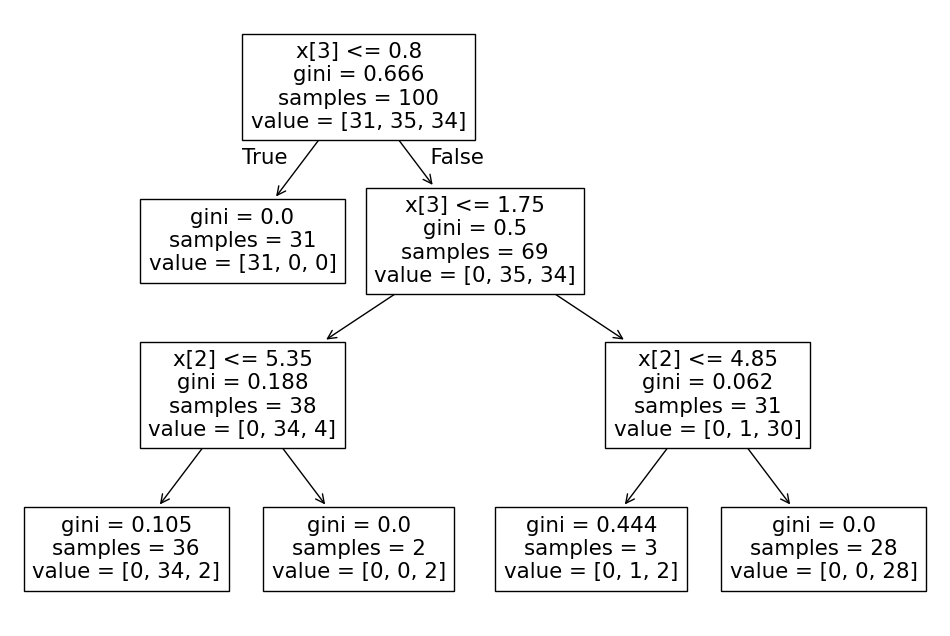

In [31]:
plt.figure(figsize=(12,8))

from sklearn import tree

tree.plot_tree(clf_gini.fit(X_train, y_train))



### Visualize decision-trees with graphviz

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')


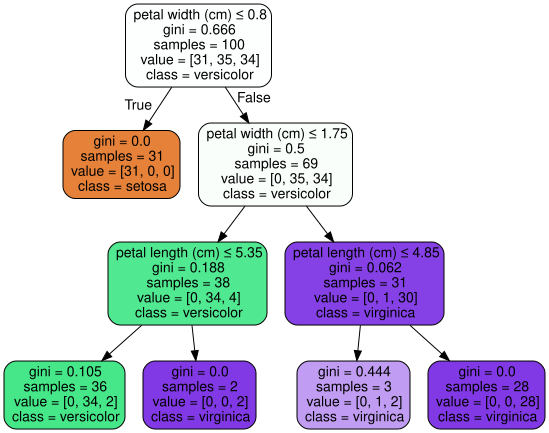

In [32]:
import graphviz
print(X_train.columns)
dot_data = tree.export_graphviz(clf_gini, out_file=None,
                                feature_names=iris.feature_names,
                                class_names=iris.target_names,
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(dot_data)
graph


# 9. Decision Tree Classifier with criterion entropy

---



In [33]:
# instantiate the DecisionTreeClassifier model with criterion entropy
clf_en = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)

# fit the model
clf_en.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

### Predict the Test set results with criterion entropy

In [34]:
y_pred_en = clf_en.predict(X_test)

### Check accuracy scores with criterion entropy

In [35]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion entropy: {0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))

Model accuracy score with criterion entropy: 0.9600


### Check for overfitting and underfitting

In [36]:
#compare training and test accuracies
print('Training set score: {:.4f}'.format(clf_en.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(clf_en.score(X_test, y_test)))

Training set score: 0.9900
Test set score: 0.9600


In [ ]:
acc_train, acc_test = [], []
for i in range(1,20):
  clf_en_i = DecisionTreeClassifier(criterion='entropy', max_depth=i, random_state=0)
  clf_en_i.fit(X_train, y_train)
  acc_train.append(clf_en_i.score(X_train, y_train))

  acc_test.append(clf_en_i.score(X_test, y_test))
pd.DataFrame(data=[acc_train,acc_test], index=['train acc','test acc'])

### Visualize decision tree with sklearn.tree

[Text(0.4444444444444444, 0.9166666666666666, 'x[3] <= 0.8\nentropy = 1.583\nsamples = 100\nvalue = [31, 35, 34]'),
 Text(0.3333333333333333, 0.75, 'entropy = 0.0\nsamples = 31\nvalue = [31, 0, 0]'),
 Text(0.38888888888888884, 0.8333333333333333, 'True  '),
 Text(0.5555555555555556, 0.75, 'x[3] <= 1.75\nentropy = 1.0\nsamples = 69\nvalue = [0, 35, 34]'),
 Text(0.5, 0.8333333333333333, '  False'),
 Text(0.3333333333333333, 0.5833333333333334, 'x[2] <= 5.35\nentropy = 0.485\nsamples = 38\nvalue = [0, 34, 4]'),
 Text(0.2222222222222222, 0.4166666666666667, 'x[3] <= 1.45\nentropy = 0.31\nsamples = 36\nvalue = [0, 34, 2]'),
 Text(0.1111111111111111, 0.25, 'entropy = 0.0\nsamples = 26\nvalue = [0, 26, 0]'),
 Text(0.3333333333333333, 0.25, 'x[1] <= 2.6\nentropy = 0.722\nsamples = 10\nvalue = [0, 8, 2]'),
 Text(0.2222222222222222, 0.08333333333333333, 'entropy = 0.918\nsamples = 3\nvalue = [0, 1, 2]'),
 Text(0.4444444444444444, 0.08333333333333333, 'entropy = 0.0\nsamples = 7\nvalue = [0, 7, 0

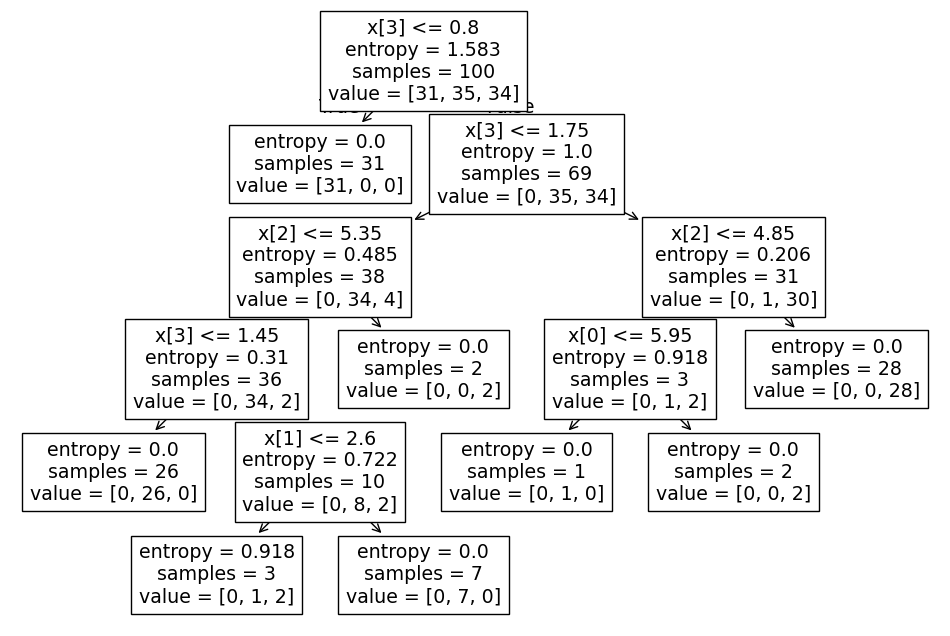

In [37]:
plt.figure(figsize=(12,8))

from sklearn import tree

tree.plot_tree(clf_en.fit(X_train, y_train))

### Visualize decision tree with graphviz

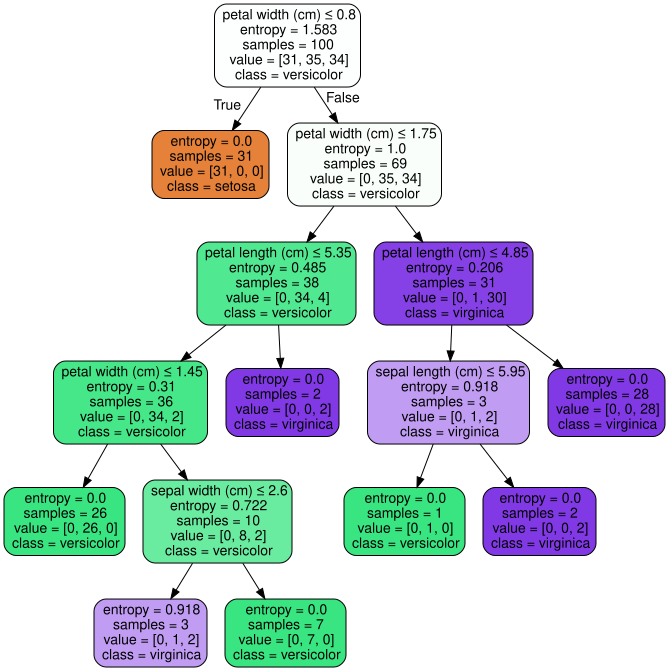

In [38]:
import graphviz
dot_data = tree.export_graphviz(clf_en, out_file=None,
                              feature_names=iris.feature_names,
                              class_names=iris.target_names,
                              filled=True, rounded=True,
                              special_characters=True)

graph = graphviz.Source(dot_data)

graph

# 10. Confusion matrix


A confusion matrix helps summarize the performance of a classification algorithm. A confusion matrix will give a clear picture of the perfomance of a classification model as well as the types of errors produced by the it. <br>
It gives a summary of correct and incorrect predictions broken down by each category.


Four types of outcomes are possible while evaluating a classification model performance :


**True Positives (TP)** – We predict that an observation belongs to a certain class *x* and the observation actually belongs to that class *x*.


**True Negatives (TN)** – We predict that an observation does not belong to a certain class *x* and the observation actually does not belong to that class *x*.


**False Positives (FP)** – We predict that an observation belongs to a certain class *x* but the observation actually **does not belong** to that class *x*. This type of error is called Type I error.



**False Negatives (FN)** – We predict that an observation does not belong to a certain class *x* but the observation **actually belongs** to that class *x*. This is a very serious error and it is called Type II error.



Confusion Matrice for GINI:


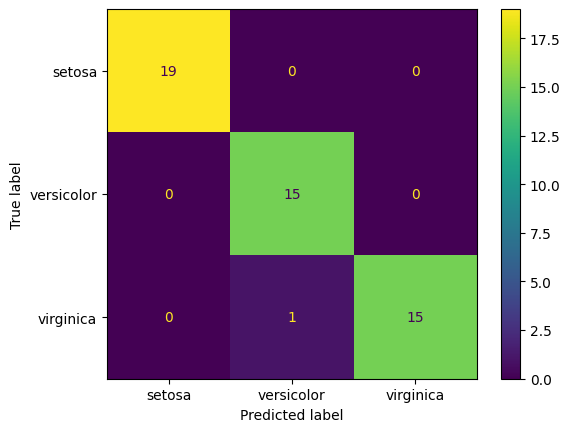

In [39]:
# Print the Confusion Matrix for GINI and identify the four pieces
# Use sklearn.metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for GINI
print("Confusion Matrice for GINI:")
cm = confusion_matrix(y_test, y_pred_gini)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.show()


Confusion Matrix for Entropy:


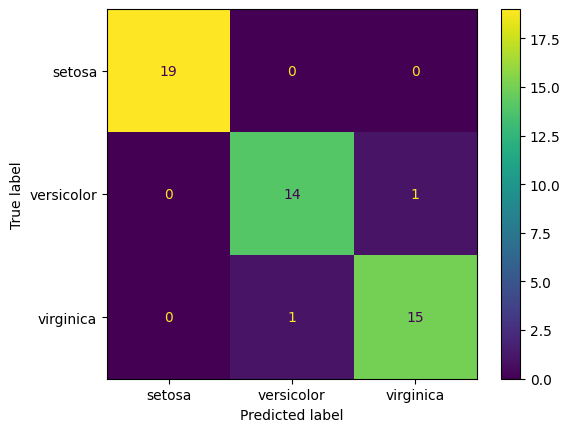

In [40]:
# Print the Confusion Matrix for Entropy and identify the four pieces
print("Confusion Matrix for Entropy:")
cm = confusion_matrix(y_test, y_pred_en)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.show()

# 11. Cross Validation

In [42]:
from sklearn.model_selection import cross_val_score

# Cross validation score for GINI with 10 different splits
scores_gini = cross_val_score(clf_gini, X, y, cv=10)
print("Cross-validation scores for GINI: {}".format(scores_gini))
print("Mean cross-validation score: {:.2f}".format(scores_gini.mean()))
print("Standard deviation of cross-validation score: {:.2f}".format(scores_gini.std()))

# Cross validation score for Entropy with 10 different splits
scores_en = cross_val_score(clf_en, X, y, cv=10)
print("\n\nCross-validation scores for Entropy: {}".format(scores_en))
print("Mean cross-validation score: {:.2f}".format(scores_en.mean()))
print("Standard deviation of cross-validation score: {:.2f}".format(scores_en.std()))




Cross-validation scores for GINI: [1.         0.93333333 1.         0.93333333 0.93333333 0.93333333
 0.93333333 0.93333333 1.         1.        ]
Mean cross-validation score: 0.96
Standard deviation of cross-validation score: 0.03


Cross-validation scores for Entropy: [1.         0.93333333 1.         0.93333333 0.93333333 0.86666667
 0.93333333 1.         1.         1.        ]
Mean cross-validation score: 0.96
Standard deviation of cross-validation score: 0.04


# 12. Classification Report

**Classification report** is another way to evaluate the classification model performance. It displays the  **precision**, **recall**, **f1** and **support** scores for the model.

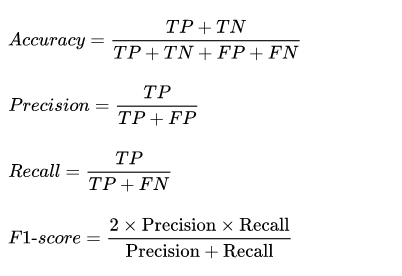

In [43]:
from sklearn.metrics import classification_report

# Classification report for GINI
print(classification_report(y_test, y_pred_gini, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [44]:
# Classification report for Entropy
print(classification_report(y_test, y_pred_en, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.93      0.93      0.93        15
   virginica       0.94      0.94      0.94        16

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50



# 13. Decision Boundaries

The two most correlated features for the classification are the petal length and the petal width whereas the two least correlated features are the sepal length and the sepal width.

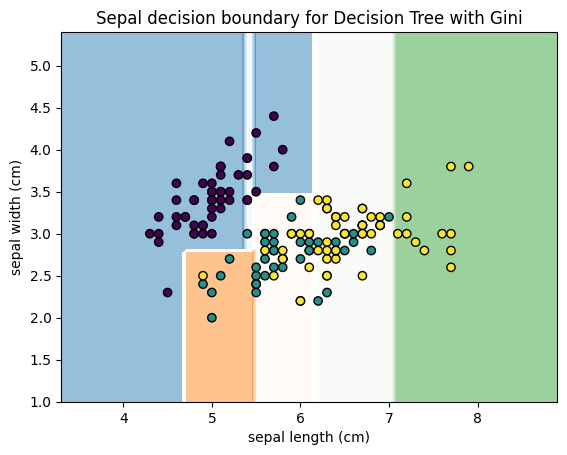

In [45]:
# Print decision boundary for decision tree with gini index
from sklearn.inspection import DecisionBoundaryDisplay
#import sklearn.inspection

# Decision boundary for sepal length and sepal width only
X = iris.data[:, :2]
sepal_classifier = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)
sepal_classifier.fit(X, iris.target)

disp = sklearn.inspection.DecisionBoundaryDisplay.from_estimator(sepal_classifier, X, xlabel=iris.feature_names[0],
                                              ylabel=iris.feature_names[1], alpha=0.5)
disp.ax_.scatter(X[:, 0], X[:, 1], c=iris.target, edgecolor="k")
plt.title("Sepal decision boundary for Decision Tree with Gini")
plt.show()

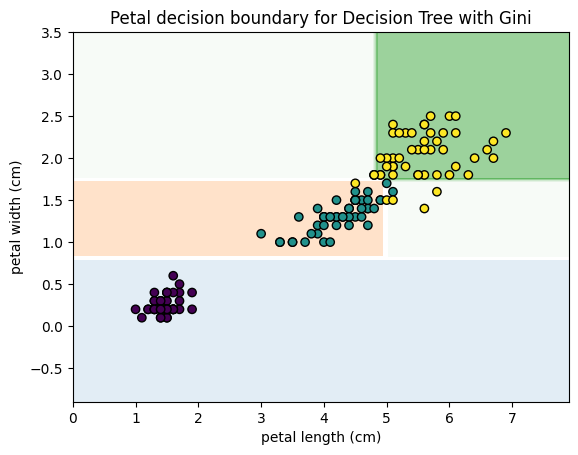

In [46]:
# Decision boundary for petal length and petal width only
X = iris.data[:, 2:]
petal_classifier = DecisionTreeClassifier(
    criterion='gini', max_depth=3, random_state=0)
petal_classifier.fit(X, iris.target)

disp = DecisionBoundaryDisplay.from_estimator(petal_classifier, X, xlabel=iris.feature_names[2],
                                              ylabel=iris.feature_names[3], alpha=0.5)
disp.ax_.scatter(X[:, 0], X[:, 1], c=iris.target, edgecolor="k")
plt.title("Petal decision boundary for Decision Tree with Gini")
plt.show()

Visually, we can see that using only the petals attributes, the classification is better than using only the sepal attributes.

# Principal Component Analysis

Principal Component Analysis is a dimensionality reduction technique. It is used to reduce the number of features in a dataset. It is used to reduce the complexity of the model and to reduce the training time. It is also used to visualise high dimensional data. <br>
https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

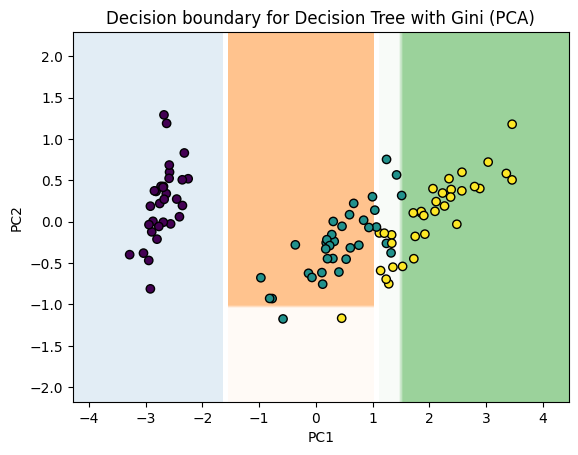

In [47]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2) # 2 principal components for 2D plot
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

pca_classifier = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)
pca_classifier.fit(X_train_pca, y_train)

disp = DecisionBoundaryDisplay.from_estimator(pca_classifier, X_train_pca, xlabel='PC1',
                                              ylabel='PC2', alpha=0.5)
disp.ax_.scatter(X_train_pca[:, 0], X_train_pca[:,
                 1], c=y_train, edgecolor="k")
plt.title("Decision boundary for Decision Tree with Gini (PCA)")
plt.show()


# References :
1. https://www.kaggle.com/code/prashant111/decision-tree-classifier-tutorial#13.-Decision-Tree-Classifier-with-criterion-gini-index-
2. https://scikit-learn.org/
3. https://www.datacamp.com/tutorial/machine-learning-in-r
4. https://www.datacamp.com/tutorial/decision-tree-classification-python
5. https://www.tutorialexample.com/an-introduction-to-accuracy-precision-recall-f1-score-in-machine-learning-machine-learning-tutorial/